# Regional Harvest Technology
**Studi Kasus: Crop Yield Prediction Dataset (1990–2013)**

---

### Daftar Isi
1. Business Understanding
2. Temuan Kunci
3. Data Understanding
4. Data Preparation
5. Modelling
6. Evaluation
7. Deployment
8. Kesimpulan

# 1. Pemahaman Bisnis (Business Understanding)

## Latar Belakang

Menurut laporan terbaru FAO (The State of Food Security and Nutrition in the World 2025), sekitar 670 juta orang di dunia masih mengalami kelaparan pada tahun 2024, dan target SDG 2 (Zero Hunger) pada 2030 diperkirakan tidak akan tercapai. Salah satu akar masalahnya adalah ketidakpastian produktivitas pertanian akibat variasi iklim dan pengelolaan sumber daya yang berbeda antar wilayah.

Dataset yang digunakan dalam analisis ini mencakup data hasil panen dari berbagai negara pada periode 1990–2013, beserta faktor curah hujan, suhu rata-rata, dan penggunaan pestisida. Dengan memodelkan hubungan antara faktor-faktor tersebut dan hasil panen, analisis ini diharapkan dapat mendukung estimasi produktivitas pertanian sebagai salah satu alat bantu perencanaan produksi pangan, sejalan dengan SDG 2 (Zero Hunger) dan SDG 13 (Climate Action).

## Tujuan

Membangun model untuk memprediksi hasil panen (hg/ha) berdasarkan:

- Wilayah (Area)
- Jenis tanaman (Item)
- Tahun
- Curah hujan
- Penggunaan pestisida
- Suhu rata-rata

## Tujuan Analisis

1. Mengidentifikasi pola hasil panen.
2. Mengetahui kontribusi faktor terhadap prediksi yield.
3. Membangun model prediksi yang memiliki performa baik.
4. Menghasilkan simulasi prediksi yang dapat digunakan sebagai
   decision-support sederhana.

## Batasan

Dataset bersifat observasional sehingga hubungan yang ditemukan
merupakan asosiasi dan tidak dapat langsung dianggap sebagai
hubungan sebab-akibat. Selain itu, terdapat kesenjangan waktu (temporal gap) yang perlu diperhatikan antara konteks permasalahan dan data yang dianalisis.

Latar belakang analisis ini merujuk pada laporan FAO tahun 2025 mengenai kondisi ketahanan pangan global saat ini, sementara dataset yang digunakan hanya mencakup periode 1990–2013 — lebih dari satu dekade sebelum kondisi yang digambarkan dalam laporan tersebut. Akibatnya, pola dan hubungan yang ditemukan dalam analisis ini (misalnya dominasi faktor wilayah dan jenis tanaman dibandingkan cuaca tahunan) mencerminkan kondisi agrikultur pada periode 1990–2013 dan belum tentu sepenuhnya merepresentasikan kondisi pertanian, teknologi budidaya, maupun pola iklim saat ini.

Perubahan iklim yang semakin signifikan dalam satu dekade terakhir juga berpotensi mengubah kekuatan hubungan antara faktor cuaca dan hasil panen dibandingkan yang teramati pada data historis ini. Oleh karena itu, hasil dan model dalam analisis ini sebaiknya dipandang sebagai studi kasus historis dan titik awal, bukan sebagai alat prediksi yang siap pakai untuk kondisi pertanian terkini tanpa validasi ulang menggunakan data yang lebih mutakhir.

# 2. Temuan Kunci

> **Wilayah dan jenis tanaman jauh lebih menentukan hasil panen dibandingkan variasi cuaca tahunan.**

Berdasarkan analisis data historis (1990–2013), model baseline yang hanya menggunakan rata-rata hasil panen per kombinasi **wilayah dan jenis tanaman** (tanpa memperhitungkan curah hujan, suhu, maupun penggunaan pestisida) sudah mampu menjelaskan sebagian besar variasi hasil panen (R² = 0,878). Sebaliknya, korelasi langsung antara faktor iklim tahunan (curah hujan, suhu, pestisida) dengan hasil panen tergolong sangat lemah (0,00–0,11).

Penambahan model machine learning (Random Forest) yang memperhitungkan faktor iklim hanya meningkatkan performa secara marginal, dari R² = 0,878 menjadi R² = 0,951. Ini mengindikasikan bahwa karakteristik agroklimat lokal jangka panjang (direpresentasikan oleh kombinasi wilayah dan jenis tanaman) adalah faktor dominan dalam menentukan produktivitas pertanian, sementara variasi cuaca tahunan berperan sebagai faktor koreksi yang lebih kecil.

# 3. Pemahaman Data (Data Understanding)

In [4]:
"""
import kagglehub

# Download versi terbaru dataset dari Kaggle
path = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")

print("Path to dataset files:", path)
"""

'\nimport kagglehub\n\n# Download versi terbaru dataset dari Kaggle\npath = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")\n\nprint("Path to dataset files:", path)\n'

In [5]:
# Import library pandas untuk melakukan pengolahan dan analisis data
import pandas as pd

# Membaca dataset crop yield dari file CSV
#df = pd.read_csv("/root/.cache/kagglehub/datasets/patelris/crop-yield-prediction-dataset/versions/7/yield_df.csv")
df = pd.read_csv("data/yield_df.csv")

# Menampilkan ukuran dataset (jumlah baris dan kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan 5 baris pertama dari dataset
df.head()

Ukuran dataset: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


Pada tahap awal, dataset dimuat menggunakan Pandas dan kemudian dilakukan pengecekan terhadap ukuran serta beberapa data pertama. Dataset yang digunakan memiliki 28.242 baris dan 8 kolom. Data ini berisi informasi mengenai wilayah, jenis tanaman, tahun, hasil produksi per hektare, curah hujan, penggunaan pestisida, dan suhu. Pengecekan lima data pertama dilakukan untuk memastikan struktur dan isi dataset sudah sesuai dengan kebutuhan analisis.

## Kamus Fitur (Data Dictionary)

Dataset ini terdiri dari 28.242 baris dan 8 kolom, dengan rincian sebagai berikut:

| Kolom | Deskripsi | Satuan/Tipe |
|---|---|---|
| `Area` | Nama negara/wilayah tempat pengamatan dilakukan | Kategorikal |
| `Item` | Jenis tanaman yang diamati (contoh: Maize, Potatoes, Rice) | Kategorikal |
| `Year` | Tahun pengamatan | 1990–2013 |
| `hg/ha_yield` | Hasil panen per hektar lahan (variabel target) | Hektogram/hektar (hg/ha) |
| `average_rain_fall_mm_per_year` | Rata-rata curah hujan tahunan di wilayah tersebut | Milimeter (mm) |
| `pesticides_tonnes` | Total penggunaan pestisida di wilayah tersebut | Ton |
| `avg_temp` | Suhu rata-rata tahunan di wilayah tersebut | Derajat Celsius (°C) |

Catatan: 1 ton/ha setara dengan 10.000 hg/ha, sehingga sepanjang analisis nilai hasil panen sering dikonversi ke ton/ha agar lebih mudah diinterpretasikan.

In [6]:
# Menghitung jumlah nilai yang hilang pada setiap kolom
missing = df.isnull().sum()

# Menampilkan jumlah nilai yang hilang pada setiap kolom
print("Jumlah nilai yang hilang:")
print(missing)

# Menampilkan total seluruh nilai yang hilang dalam dataset
print("\nTotal nilai yang hilang:", missing.sum())

Jumlah nilai yang hilang:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Total nilai yang hilang: 0


Selanjutnya dilakukan pengecekan nilai yang hilang untuk memastikan apakah terdapat data yang kosong pada setiap variabel. Hasil pemeriksaan menunjukkan bahwa seluruh variabel memiliki 0 nilai hilang, sehingga dari sisi kelengkapan data, seluruh 28.242 observasi telah terisi dan tidak diperlukan proses penanganan nilai hilang.

In [7]:
# Menghitung dan menampilkan jumlah data yang memiliki baris duplikat
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Selanjutnya dilakukan pengecekan data duplikat untuk memastikan tidak ada baris data yang tercatat lebih dari satu kali. Hasil pemeriksaan menunjukkan jumlah data duplikat adalah 0, sehingga seluruh baris dalam dataset tidak memiliki duplikasi yang identik dan data dapat dilanjutkan ke tahap analisis berikutnya.

In [8]:
# Memeriksa apakah terdapat kolom "Unnamed: 0" pada dataset
if "Unnamed: 0" in df.columns:
    # Menghapus kolom "Unnamed: 0" karena tidak diperlukan dalam analisis
    df = df.drop(columns=["Unnamed: 0"])

# Menampilkan 5 baris pertama setelah penghapusan kolom
print(df.head())

      Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990        36613                         1485.0   
1  Albania     Potatoes  1990        66667                         1485.0   
2  Albania  Rice, paddy  1990        23333                         1485.0   
3  Albania      Sorghum  1990        12500                         1485.0   
4  Albania     Soybeans  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     16.37  
2              121.0     16.37  
3              121.0     16.37  
4              121.0     16.37  


Pada tahap data cleaning, kami menghapus kolom Unnamed: 0 karena kolom tersebut hanya merupakan nomor indeks dari dataset dan tidak memberikan informasi yang dibutuhkan dalam proses analisis maupun prediksi hasil panen. Setelah kolom tersebut dihapus, dilakukan pengecekan menggunakan head() untuk memastikan bahwa data sudah bersih dan kolom yang digunakan hanya merupakan variabel yang relevan.

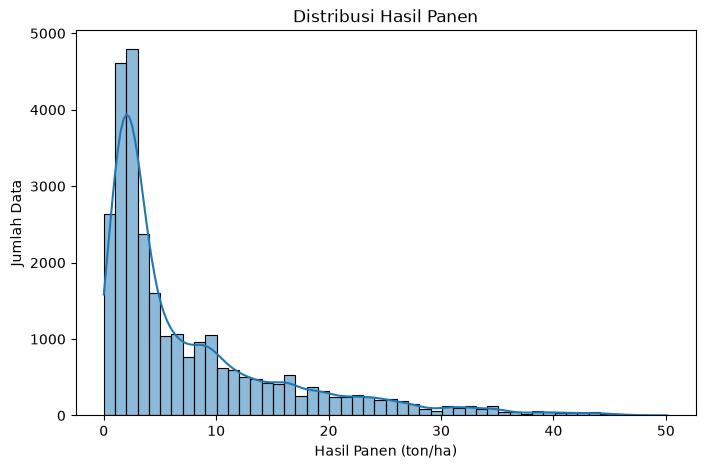

In [9]:
# Mengimpor pustaka untuk membuat visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur ukuran gambar visualisasi
plt.figure(figsize=(8,5))

# Membuat grafik distribusi hasil panen
# Membagi nilai hg/ha_yield dengan 10.000 untuk mengubah satuan menjadi ton/ha
sns.histplot(
    df["hg/ha_yield"] / 10000,
    bins=50,
    kde=True
)

# Memberikan judul dan nama pada sumbu grafik
plt.title("Distribusi Hasil Panen")
plt.xlabel("Hasil Panen (ton/ha)")
plt.ylabel("Jumlah Data")

# Menampilkan grafik
plt.show()

Grafik ini menunjukkan bagaimana hasil panen tersebar pada seluruh data yang digunakan. Sumbu horizontal menunjukkan hasil panen dalam ton per hektare, sedangkan sumbu vertikal menunjukkan jumlah data. Dari grafik terlihat bahwa sebagian besar data memiliki hasil panen di bawah sekitar 10 ton per hektare. Jumlah data semakin sedikit ketika hasil panen semakin tinggi.

Di sisi kanan grafik masih terdapat beberapa data dengan hasil panen yang cukup tinggi, bahkan mencapai sekitar 50 ton per hektare. Artinya, hanya sebagian kecil data yang memiliki hasil panen jauh lebih tinggi dibandingkan sebagian besar data. Temuan ini menunjukkan bahwa hasil panen dalam dataset memiliki rentang yang cukup lebar dan persebarannya tidak merata. Oleh karena itu, kondisi tersebut perlu diperhatikan dalam tahap pengolahan data dan pemodelan.

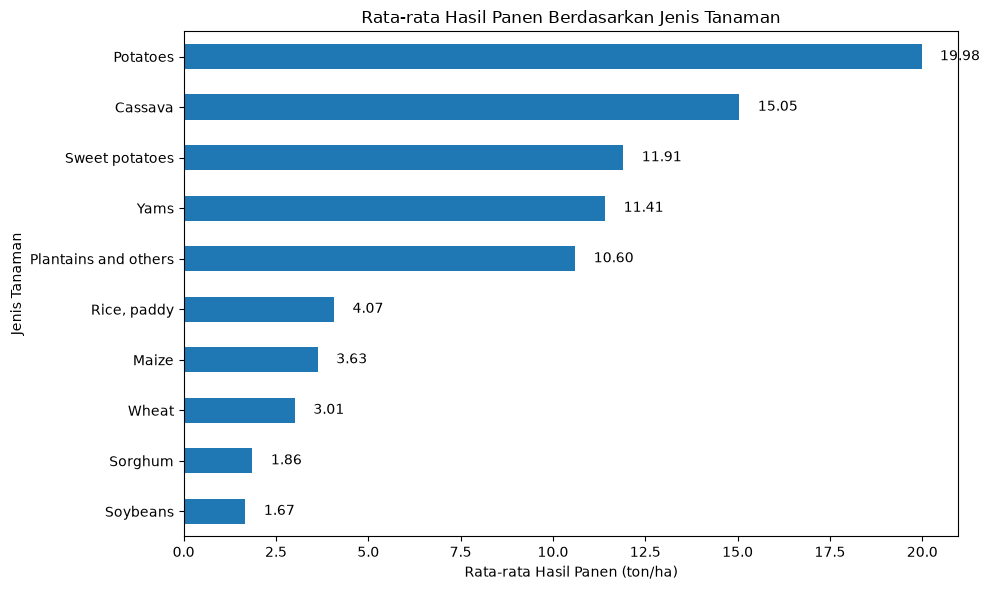

In [10]:
# Mengelompokkan data berdasarkan jenis tanaman dan menghitung rata-rata hasil panen
yield_item = (
    df.groupby("Item")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
)

# Mengubah satuan hasil panen dari hg/ha menjadi ton/ha
yield_item = yield_item / 10000

# Mengurutkan data dari hasil panen terendah ke tertinggi
# agar tampilan grafik batang lebih mudah dibaca
yield_item = yield_item.sort_values()

# Mengatur ukuran grafik
plt.figure(figsize=(10, 6))

# Membuat grafik batang horizontal
ax = yield_item.plot(kind="barh")

# Memberikan judul dan keterangan pada sumbu grafik
plt.title("Rata-rata Hasil Panen Berdasarkan Jenis Tanaman")
plt.xlabel("Rata-rata Hasil Panen (ton/ha)")
plt.ylabel("Jenis Tanaman")

# Menampilkan nilai rata-rata pada setiap batang grafik
for i, value in enumerate(yield_item):
    ax.text(
        value + 0.5,
        i,
        f"{value:.2f}",
        va="center"
    )

# Mengatur tata letak grafik agar tidak saling bertumpuk
plt.tight_layout()

# Menampilkan grafik
plt.show()

Grafik ini menunjukkan perbedaan rata-rata hasil panen dari berbagai jenis tanaman dalam satu hektare lahan. Terlihat bahwa kentang memiliki rata-rata hasil panen paling tinggi, yaitu sekitar 19,98 ton per hektare. Setelah itu terdapat singkong sebesar 15,05 ton per hektare dan ubi jalar sebesar 11,91 ton per hektare. Sementara itu, kedelai memiliki rata-rata hasil panen paling rendah, yaitu sekitar 1,67 ton per hektare.

Dari grafik tersebut dapat dilihat bahwa setiap jenis tanaman memiliki rata-rata hasil panen yang berbeda cukup jauh. Hal ini menunjukkan bahwa jenis tanaman merupakan salah satu informasi penting yang perlu dipertimbangkan ketika melakukan prediksi hasil panen.

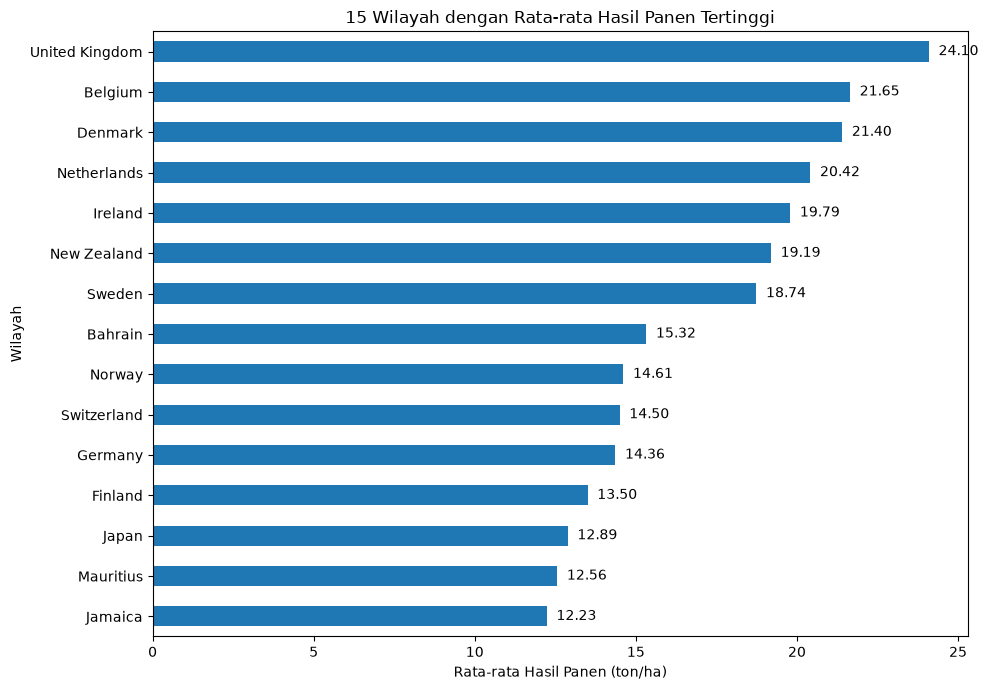

In [11]:
# Mengelompokkan data berdasarkan wilayah dan menghitung rata-rata hasil panen
# kemudian mengambil 15 wilayah dengan rata-rata hasil panen tertinggi
rata_area = (
    df.groupby("Area")["hg/ha_yield"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Mengubah satuan hasil panen dari hg/ha menjadi ton/ha
rata_area = rata_area / 10000

# Mengurutkan data dari hasil panen terendah ke tertinggi
# agar tampilan grafik lebih mudah dibaca
rata_area = rata_area.sort_values()

# Mengatur ukuran grafik
plt.figure(figsize=(10, 7))

# Membuat grafik batang horizontal
ax = rata_area.plot(
    kind="barh",
    figsize=(10, 7)
)

# Memberikan judul dan keterangan pada sumbu grafik
plt.title(
    "15 Wilayah dengan Rata-rata Hasil Panen Tertinggi"
)

plt.xlabel("Rata-rata Hasil Panen (ton/ha)")
plt.ylabel("Wilayah")

# Menampilkan nilai rata-rata pada setiap batang grafik
for i, value in enumerate(rata_area):
    ax.text(
        value + 0.3,
        i,
        f"{value:.2f}",
        va="center"
    )

# Mengatur tata letak grafik agar tidak saling bertumpuk
plt.tight_layout()

# Menampilkan grafik
plt.show()

Grafik ini menunjukkan 15 wilayah yang memiliki rata-rata hasil panen per hektare paling tinggi dalam dataset. Dari grafik terlihat bahwa United Kingdom memiliki rata-rata hasil panen tertinggi, yaitu sekitar 24,10 ton per hektare. Selanjutnya adalah Belgium sebesar 21,65 ton per hektare dan Denmark sebesar 21,40 ton per hektare.

Sementara itu, Jamaica berada di posisi ke-15 dengan rata-rata 12,23 ton per hektare. Perbedaan ini menunjukkan bahwa rata-rata hasil panen tidak sama di setiap wilayah. Hal tersebut menjadi indikasi bahwa karakteristik wilayah merupakan informasi yang penting untuk dipertimbangkan dalam melakukan prediksi hasil panen.

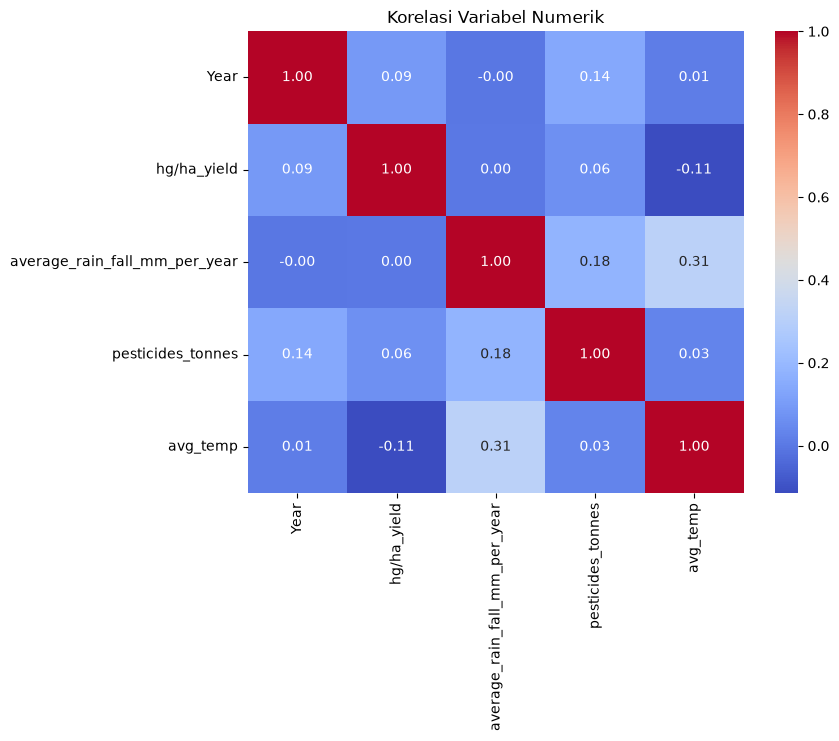

In [12]:
# Menentukan kolom numerik yang akan digunakan untuk analisis korelasi
numeric_cols = [
    "Year",
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Mengatur ukuran grafik
plt.figure(figsize=(8, 6))

# Membuat peta panas untuk melihat hubungan antarvariabel numerik
# Nilai korelasi berada pada rentang -1 hingga 1
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Memberikan judul pada grafik
plt.title("Korelasi Variabel Numerik")

# Menampilkan grafik
plt.show()

Dari grafik terlihat bahwa hubungan antara tahun dan hasil panen hanya sebesar 0,09, sehingga hubungannya sangat lemah. Hubungan antara curah hujan dan hasil panen adalah 0,00, sedangkan jumlah penggunaan pestisida dan hasil panen sebesar 0,06. Artinya, berdasarkan data ini, hubungan langsung kedua faktor tersebut dengan hasil panen terlihat sangat lemah.

Sementara itu, suhu rata-rata dan hasil panen memiliki nilai -0,11. Tanda negatif menunjukkan bahwa ketika suhu meningkat, hasil panen dalam data cenderung sedikit menurun, tetapi hubungannya juga masih sangat lemah. Hubungan numerik yang paling terlihat pada grafik adalah curah hujan dengan suhu rata-rata, yaitu 0,31, tetapi hubungan ini juga masih tergolong lemah.

# 4. Persiapan Data (Data Preparation)

In [13]:
# Mengimpor pustaka NumPy untuk melakukan operasi matematika
import numpy as np

# Membuat kolom baru dengan menerapkan transformasi logaritma pada hasil panen
# log1p digunakan agar tetap aman ketika terdapat nilai hasil panen sebesar 0
df["log_yield"] = np.log1p(df["hg/ha_yield"])

# Menampilkan lima baris pertama untuk membandingkan nilai hasil panen
# sebelum dan sesudah transformasi logaritma
print(df[["hg/ha_yield", "log_yield"]].head())

   hg/ha_yield  log_yield
0        36613  10.508186
1        66667  11.107480
2        23333  10.057667
3        12500   9.433564
4         7000   8.853808


Pada tahap ini, kita melakukan transformasi data hasil panen. Sebelumnya, dari grafik distribusi hasil panen, kita sudah melihat bahwa nilai hasil panen memiliki rentang yang sangat lebar. Sebagian besar data berada pada nilai yang relatif rendah, tetapi ada sebagian kecil data dengan hasil panen yang sangat tinggi, sehingga kita perlu mengubahnya ke dalam bentuk logaritma. Tujuannya adalah untuk mengecilkan perbedaan skala antar nilai agar data lebih terkendali dan lebih mudah digunakan dalam proses pemodelan. Data hasil panen asli tetap dipertahankan, sedangkan hasil transformasinya disimpan sebagai kolom baru log_yield





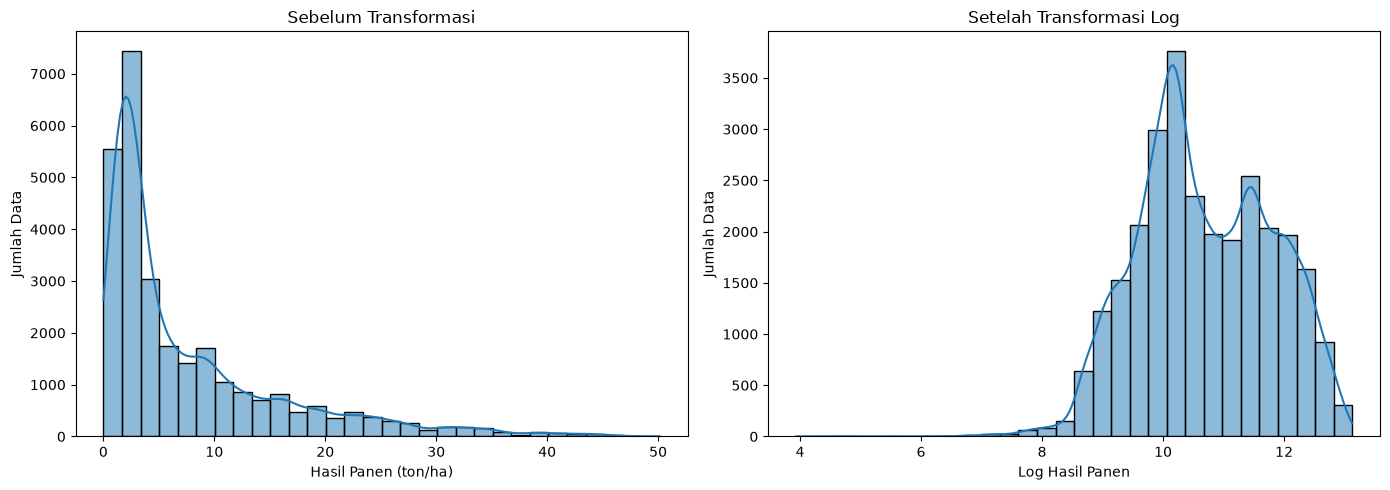

In [14]:
# Membuat dua grafik berdampingan untuk membandingkan distribusi data
# sebelum dan sesudah dilakukan transformasi logaritma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Membuat grafik distribusi hasil panen sebelum transformasi
sns.histplot(
    df["hg/ha_yield"] / 10000,
    bins=30,
    kde=True,
    ax=axes[0]
)

# Memberikan judul dan keterangan pada grafik pertama
axes[0].set_title("Sebelum Transformasi")
axes[0].set_xlabel("Hasil Panen (ton/ha)")
axes[0].set_ylabel("Jumlah Data")


# Membuat grafik distribusi hasil panen setelah transformasi logaritma
sns.histplot(
    df["log_yield"],
    bins=30,
    kde=True,
    ax=axes[1]
)

# Memberikan judul dan keterangan pada grafik kedua
axes[1].set_title("Setelah Transformasi Log")
axes[1].set_xlabel("Log Hasil Panen")
axes[1].set_ylabel("Jumlah Data")

# Mengatur tata letak agar kedua grafik tidak saling bertumpuk
plt.tight_layout()

# Menampilkan kedua grafik
plt.show()

Gambar ini membandingkan persebaran hasil panen sebelum dan sesudah dilakukan transformasi logaritma. Pada grafik sebelah kiri, yaitu sebelum transformasi, sebagian besar hasil panen berada pada nilai yang rendah, sementara hanya sedikit data yang memiliki hasil panen sangat tinggi hingga sekitar 50 ton per hektare. Akibatnya, persebaran data terlihat memanjang ke arah kanan.

Pada grafik sebelah kanan, yaitu setelah transformasi log, rentang nilai menjadi lebih terkendali. Nilai hasil panen yang sebelumnya memiliki perbedaan sangat besar sekarang berada pada rentang yang lebih sempit. Persebaran data juga menjadi lebih merata dibandingkan sebelumnya. Dengan demikian, transformasi log membantu mengurangi kemiringan persebaran data dan membuat skala hasil panen lebih terkendali untuk digunakan dalam proses pemodelan.

In [15]:
# Menentukan tahun terakhir yang digunakan untuk data pelatihan
TRAIN_CUTOFF = 2009

# Membagi data menjadi data pelatihan dan data pengujian berdasarkan tahun
# Data dengan tahun 2009 atau sebelumnya digunakan untuk pelatihan
train_df = df[df["Year"] <= TRAIN_CUTOFF].copy()

# Data setelah tahun 2009 digunakan untuk pengujian
test_df = df[df["Year"] > TRAIN_CUTOFF].copy()

# Menampilkan ukuran data pelatihan dan data pengujian
print("Data pelatihan:", train_df.shape)
print("Data pengujian :", test_df.shape)

# Menampilkan rentang tahun yang terdapat pada data pelatihan
print("\nTahun data pelatihan:",
      train_df["Year"].min(),
      "-",
      train_df["Year"].max())

# Menampilkan rentang tahun yang terdapat pada data pengujian
print("Tahun data pengujian :",
      test_df["Year"].min(),
      "-",
      test_df["Year"].max())

Data pelatihan: (23233, 8)
Data pengujian : (5009, 8)

Tahun data pelatihan: 1990 - 2009
Tahun data pengujian : 2010 - 2013


Pada tahap ini, kita melakukan pembagian data menjadi data latih (train) dan data uji (test) berdasarkan tahun. Data tahun 1990–2009 digunakan sebagai data latih agar model dapat mempelajari pola hasil panen dari data masa lalu, sedangkan data tahun 2010–2013 digunakan sebagai data uji untuk melihat apakah model mampu memberikan prediksi yang baik pada periode setelahnya. Pembagian berdasarkan waktu ini dipilih agar proses pengujian lebih mendekati kondisi nyata, yaitu model belajar dari data masa lalu kemudian digunakan untuk memprediksi data di masa berikutnya.

Output Train: (23233, 8) menunjukkan bahwa terdapat 23.233 data dengan 8 variabel yang digunakan untuk melatih model. Sementara Test: (5009, 8) berarti terdapat 5.009 data dengan 8 variabel yang disimpan untuk menguji model. Jadi, dari total 28.242 data, sebanyak 23.233 digunakan untuk belajar dan 5.009 digunakan untuk pengujian. Pembagian tahun yang ditampilkan juga memastikan bahwa data masa depan (2010–2013) tidak ikut digunakan saat model belajar, sehingga hasil evaluasi menjadi lebih realistis.

In [16]:
# Menghitung rata-rata hasil panen berdasarkan kombinasi wilayah dan jenis tanaman
# dari data pelatihan sebagai dasar untuk membuat prediksi
baseline_map = (
    train_df
    .groupby(["Area", "Item"])["log_yield"]
    .mean()
)

# Menghitung rata-rata hasil panen secara keseluruhan dari data pelatihan
# yang digunakan sebagai nilai cadangan jika kombinasi wilayah dan tanaman tidak ditemukan
global_mean = train_df["log_yield"].mean()


# Membuat fungsi untuk menghasilkan prediksi menggunakan model dasar
def get_baseline_prediction(data):
    return data.apply(
        lambda row: baseline_map.get(
            (row["Area"], row["Item"]),
            global_mean
        ),
        axis=1
    )


# Menghasilkan prediksi model dasar untuk data pelatihan
train_df["baseline_log_pred"] = get_baseline_prediction(train_df)

# Menghasilkan prediksi model dasar untuk data pengujian
test_df["baseline_log_pred"] = get_baseline_prediction(test_df)

Kode baseline_map digunakan untuk menghitung rata-rata log_yield berdasarkan Area dan Item, sedangkan global_mean digunakan sebagai nilai cadangan apabila terdapat kombinasi wilayah dan tanaman pada data uji yang sebelumnya tidak ditemukan pada data latih. Setelah itu, hasil rata-rata tersebut dimasukkan ke kolom baru bernama baseline_log_pred pada data train dan test.

Tujuan utamanya adalah membuat titik pembanding. Nanti setelah kita membuat model seperti Random Forest atau XGBoost, performanya akan dibandingkan dengan baseline ini. Kalau model machine learning ternyata memberikan hasil yang jauh lebih baik daripada baseline, berarti model tersebut memang berhasil menemukan pola yang lebih kompleks daripada sekadar menggunakan rata-rata hasil panen.

In [17]:
# Menghitung selisih antara nilai hasil panen sebenarnya
# dengan hasil prediksi dari model dasar pada data pelatihan
train_df["residual"] = (
    train_df["log_yield"]
    - train_df["baseline_log_pred"]
)

# Menghitung selisih antara nilai hasil panen sebenarnya
# dengan hasil prediksi dari model dasar pada data pengujian
test_df["residual"] = (
    test_df["log_yield"]
    - test_df["baseline_log_pred"]
)

# Menampilkan ringkasan statistik dari nilai selisih pada data pelatihan
print(train_df["residual"].describe())

count    2.323300e+04
mean    -2.936001e-17
std      2.153675e-01
min     -2.503371e+00
25%     -8.567281e-02
50%      3.659983e-03
75%      9.314335e-02
max      2.298740e+00
Name: residual, dtype: float64


Pada tahap ini, kita sedang melakukan analisis residual, yaitu melihat seberapa jauh hasil prediksi baseline berbeda dari hasil panen yang sebenarnya. Sederhananya, residual adalah selisih antara nilai sebenarnya dengan nilai yang diprediksi. Tujuannya adalah untuk mengetahui apakah prediksi baseline sudah cukup mendekati kondisi sebenarnya atau masih memiliki kesalahan yang cukup besar.

Output tersebut menunjukkan ringkasan dari 23.233 residual pada data train. Nilai mean hampir 0 (-3,30 × 10⁻¹⁷), yang menunjukkan bahwa secara rata-rata kesalahan prediksi berada di sekitar nol. Nilai 50% atau median adalah 0,00366, sehingga setengah data memiliki residual di bawah nilai tersebut dan setengah lainnya di atasnya. Sementara itu, residual terkecil adalah -2,50 dan terbesar 2,30, yang menunjukkan bahwa pada beberapa data terdapat perbedaan yang cukup jauh antara hasil sebenarnya dan prediksi baseline.

In [18]:
# Menentukan variabel yang akan digunakan sebagai fitur dalam pemodelan
FEATURES = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

# Menambahkan fitur interaksi sederhana antara curah hujan dan suhu
# Fitur ini digunakan untuk menangkap kemungkinan hubungan antara kedua variabel
for data in [train_df, test_df]:

    data["rainfall_temp"] = (
        data["average_rain_fall_mm_per_year"]
        * data["avg_temp"]
    )

# Menambahkan fitur interaksi yang telah dibuat ke dalam daftar fitur
FEATURES += [
    "rainfall_temp"
]

Pada tahap ini, kita sedang melakukan pemilihan dan penambahan fitur (feature engineering) sebelum data dimasukkan ke model. Sederhananya, kita memilih informasi yang dianggap dapat membantu model memprediksi hasil panen, kemudian membuat satu informasi tambahan dari data yang sudah ada agar model dapat menangkap hubungan yang lebih kompleks.

Fitur awal yang digunakan adalah tahun, curah hujan, jumlah penggunaan pestisida, dan suhu rata-rata. Kemudian kita membuat fitur rainfall_temp, yaitu perkalian antara curah hujan dan suhu. Tujuannya adalah memberikan informasi kepada model mengenai kombinasi kondisi curah hujan dan suhu, bukan hanya melihat keduanya secara terpisah, karena efek curah hujan terhadap hasil panen bisa berbeda tergantung suhu saat itu terjadi.

In [19]:
# Mengubah kategori jenis tanaman pada data pelatihan menjadi variabel biner
# menggunakan metode pengkodean satu-panas
item_train = pd.get_dummies(
    train_df["Item"],
    prefix="item"
)

# Mengubah kategori jenis tanaman pada data pengujian menjadi variabel biner
# menggunakan metode pengkodean satu-panas
item_test = pd.get_dummies(
    test_df["Item"],
    prefix="item"
)

# Menyamakan kolom pada data pelatihan dan data pengujian
# agar keduanya memiliki struktur fitur yang sama
item_test = item_test.reindex(
    columns=item_train.columns,
    fill_value=0
)

Pada tahap ini, kita sedang melakukan pengubahan data jenis tanaman menjadi bentuk angka agar bisa dibaca oleh model machine learning. Kolom Item berisi nama tanaman seperti Wheat, Potatoes, Rice, dan sebagainya, sehingga tidak bisa langsung digunakan oleh sebagian besar model dalam bentuk teks. Oleh karena itu, kita menggunakan one-hot encoding, yaitu mengubah setiap jenis tanaman menjadi kolom tersendiri yang berisi nilai 1 jika tanaman tersebut sesuai dan 0 jika tidak.

In [20]:
# Menggabungkan fitur numerik dengan fitur jenis tanaman yang telah diubah
# menjadi variabel biner untuk membentuk data masukan pelatihan
X_train = pd.concat(
    [
        train_df[FEATURES].reset_index(drop=True),
        item_train.reset_index(drop=True)
    ],
    axis=1
)

# Menggabungkan fitur numerik dengan fitur jenis tanaman yang telah diubah
# menjadi variabel biner untuk membentuk data masukan pengujian
X_test = pd.concat(
    [
        test_df[FEATURES].reset_index(drop=True),
        item_test.reset_index(drop=True)
    ],
    axis=1
)

# Menentukan nilai target yang akan dipelajari oleh model
# Target berupa selisih antara hasil sebenarnya dan prediksi model dasar
y_train = train_df["residual"]
y_test = test_df["residual"]

# Menampilkan jumlah fitur serta ukuran data pelatihan dan pengujian
print("Jumlah fitur:", X_train.shape[1])
print("Data pelatihan:", X_train.shape)
print("Data pengujian :", X_test.shape)

Jumlah fitur: 15
Data pelatihan: (23233, 15)
Data pengujian : (5009, 15)


Pada tahap ini, kita sedang menyatukan seluruh informasi yang sudah disiapkan menjadi data akhir yang akan digunakan untuk melatih dan menguji model machine learning. Jadi, sebelumnya kita sudah membuat beberapa fitur numerik seperti tahun, curah hujan, pestisida, suhu, serta fitur tambahan, dan juga mengubah jenis tanaman menjadi angka 0 dan 1 menggunakan one-hot encoding. Sekarang semua fitur tersebut digabungkan menjadi satu tabel yang disebut X, yaitu informasi yang akan dibaca oleh model. Sementara itu, y berisi nilai yang ingin diprediksi oleh model, yaitu residual atau kesalahan prediksi baseline.

Output Jumlah fitur: 15 berarti setelah semua informasi digabungkan, model akan menerima 15 variabel sebagai bahan untuk membuat prediksi. X_train: (23233, 15) berarti terdapat 23.233 data latihan dengan 15 variabel, sedangkan X_test: (5009, 15) berarti terdapat 5.009 data pengujian dengan 15 variabel. Jadi, pada tahap ini kita sudah memiliki bentuk data yang siap diberikan kepada model: 23.233 data untuk belajar dan 5.009 data untuk menguji kemampuan model.

# 5. Pemodelan (Modelling)

In [21]:
# PEMODELAN - PERBANDINGAN BEBERAPA ALGORITMA

# Mengimpor algoritma yang akan digunakan untuk pemodelan
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Membuat model Regresi Linear
linear_model = LinearRegression()

# Melatih model menggunakan data pelatihan
linear_model.fit(
    X_train,
    y_train
)

# Menampilkan informasi bahwa model telah berhasil dilatih
print("Regresi Linear berhasil dilatih.")

# Membuat model Random Forest dengan 300 pohon keputusan
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Melatih model menggunakan data pelatihan
rf_model.fit(
    X_train,
    y_train
)

# Menampilkan informasi bahwa model telah berhasil dilatih
print("Random Forest berhasil dilatih.")

# Membuat model XGBoost dengan parameter yang telah ditentukan
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Melatih model menggunakan data pelatihan
xgb_model.fit(
    X_train,
    y_train
)

# Menampilkan informasi bahwa model telah berhasil dilatih
print("XGBoost berhasil dilatih.")

Regresi Linear berhasil dilatih.
Random Forest berhasil dilatih.
XGBoost berhasil dilatih.


Pada tahap ini kita masuk ke proses pemodelan (modeling). Tujuannya adalah melatih beberapa algoritma machine learning menggunakan data X_train sebagai informasi atau faktor yang digunakan untuk melakukan prediksi, sedangkan y_train merupakan nilai yang ingin diprediksi, yaitu residual dari log yield. Kita menggunakan tiga algoritma, yaitu Regresi Linear, Random Forest, dan XGBoost, agar dapat mengetahui pendekatan mana yang paling sesuai untuk data hasil panen. Ketiga model dilatih menggunakan data dan kondisi yang sama sehingga hasilnya dapat dibandingkan secara adil.

Regresi Linear digunakan sebagai model sederhana atau pembanding awal. Model ini mencoba menemukan hubungan garis lurus antara faktor-faktor seperti tahun, curah hujan, pestisida, suhu, dan jenis tanaman dengan residual hasil panen. Random Forest menggunakan banyak pohon keputusan dan menggabungkan hasilnya untuk menghasilkan prediksi yang lebih stabil. Sementara itu, XGBoost juga menggunakan pohon keputusan, tetapi membangunnya secara bertahap dengan berusaha memperbaiki kesalahan prediksi dari model sebelumnya. Dengan demikian, ketiga algoritma memiliki pendekatan yang berbeda dalam mempelajari pola data.

Bagian seperti n_estimators=300 pada Random Forest berarti model membuat 300 pohon keputusan. Pada XGBoost, n_estimators=400 berarti menggunakan hingga 400 tahap/pohon, sedangkan max_depth=4 membatasi kedalaman setiap pohon agar model tidak terlalu kompleks. learning_rate=0.05 mengatur seberapa besar kontribusi setiap tahap XGBoost terhadap hasil akhir. random_state=42 digunakan agar proses yang memiliki unsur acak dapat menghasilkan hasil yang konsisten ketika kode dijalankan kembali.

In [22]:
# MENGHASILKAN PREDIKSI NILAI SELISIH

# Menghasilkan prediksi nilai selisih menggunakan model Regresi Linear
predicted_residual_linear = linear_model.predict(X_test)

# Menghasilkan prediksi nilai selisih menggunakan model Random Forest
predicted_residual_rf = rf_model.predict(X_test)

# Menghasilkan prediksi nilai selisih menggunakan model XGBoost
predicted_residual_xgb = xgb_model.predict(X_test)

# MENGGABUNGKAN PREDIKSI DENGAN NILAI DASAR

# Menggabungkan prediksi nilai dasar dengan prediksi selisih
# untuk memperoleh prediksi dalam skala logaritma
predicted_log_linear = (
    test_df["baseline_log_pred"].values
    + predicted_residual_linear
)

predicted_log_rf = (
    test_df["baseline_log_pred"].values
    + predicted_residual_rf
)

predicted_log_xgb = (
    test_df["baseline_log_pred"].values
    + predicted_residual_xgb
)

# MENGEMBALIKAN KE SKALA ASLI

# Mengembalikan hasil prediksi dari skala logaritma ke skala asli
predicted_yield_linear = np.expm1(predicted_log_linear)
predicted_yield_rf = np.expm1(predicted_log_rf)
predicted_yield_xgb = np.expm1(predicted_log_xgb)

# MEMASTIKAN HASIL PREDIKSI TIDAK NEGATIF

# Mengubah nilai prediksi negatif menjadi nol
predicted_yield_linear = np.clip(
    predicted_yield_linear, 0, None
)

predicted_yield_rf = np.clip(
    predicted_yield_rf, 0, None
)

predicted_yield_xgb = np.clip(
    predicted_yield_xgb, 0, None
)

Pada tahap ini, tiga algoritma yang sudah dilatih digunakan untuk memprediksi data yang belum mereka lihat, yaitu data test. Masing-masing model terlebih dahulu memprediksi residual atau perbaikan terhadap baseline. Prediksi tersebut kemudian digabungkan dengan baseline, dikembalikan dari skala log ke skala yield asli, dan dipastikan tidak menghasilkan nilai negatif. Hasil akhirnya adalah tiga prediksi yield yang nantinya digunakan untuk membandingkan Regresi Linear, Random Forest, dan XGBoost menggunakan MAE, RMSE, dan R².

# 6. Evaluasi (Evaluation)

In [23]:
# Mengimpor metrik untuk mengevaluasi kinerja model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# EVALUASI SEMUA MODEL

# Mengambil nilai hasil panen sebenarnya dari data pengujian
actual_yield = test_df["hg/ha_yield"].values

# 1. Regresi Linear

# Menghitung rata-rata kesalahan absolut
mae_linear = mean_absolute_error(
    actual_yield,
    predicted_yield_linear
)

# Menghitung akar dari rata-rata kesalahan kuadrat
rmse_linear = np.sqrt(
    mean_squared_error(
        actual_yield,
        predicted_yield_linear
    )
)

# Menghitung koefisien determinasi R²
r2_linear = r2_score(
    actual_yield,
    predicted_yield_linear
)

# 2. Random Forest
# Menghitung rata-rata kesalahan absolut
mae_rf = mean_absolute_error(
    actual_yield,
    predicted_yield_rf
)

# Menghitung akar dari rata-rata kesalahan kuadrat
rmse_rf = np.sqrt(
    mean_squared_error(
        actual_yield,
        predicted_yield_rf
    )
)

# Menghitung koefisien determinasi R²
r2_rf = r2_score(
    actual_yield,
    predicted_yield_rf
)


# 3. XGBoost
# Menghitung rata-rata kesalahan absolut
mae_xgb = mean_absolute_error(
    actual_yield,
    predicted_yield_xgb
)

# Menghitung akar dari rata-rata kesalahan kuadrat
rmse_xgb = np.sqrt(
    mean_squared_error(
        actual_yield,
        predicted_yield_xgb
    )
)

# Menghitung koefisien determinasi R²
r2_xgb = r2_score(
    actual_yield,
    predicted_yield_xgb
)

# MENAMPILKAN HASIL EVALUASI

print("=== HASIL EVALUASI ===")

# Menampilkan hasil evaluasi Regresi Linear
print("\nRegresi Linear")
print(f"MAE  : {mae_linear:,.2f}")
print(f"RMSE : {rmse_linear:,.2f}")
print(f"R²   : {r2_linear:.4f}")

# Menampilkan hasil evaluasi Random Forest
print("\nRandom Forest")
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

# Menampilkan hasil evaluasi XGBoost
print("\nXGBoost")
print(f"MAE  : {mae_xgb:,.2f}")
print(f"RMSE : {rmse_xgb:,.2f}")
print(f"R²   : {r2_xgb:.4f}")

=== HASIL EVALUASI ===

Regresi Linear
MAE  : 14,519.96
RMSE : 26,669.21
R²   : 0.9221

Random Forest
MAE  : 10,517.10
RMSE : 21,083.56
R²   : 0.9513

XGBoost
MAE  : 12,982.28
RMSE : 24,802.62
R²   : 0.9326


Pada tahap ini kita melakukan evaluasi dan perbandingan performa tiga algoritma yang sebelumnya sudah dilatih, yaitu Regresi Linear, Random Forest, dan XGBoost. Tujuannya adalah mengetahui seberapa dekat hasil prediksi masing-masing model dengan hasil panen sebenarnya (actual_yield) pada data test. Karena ketiga model menggunakan data test yang sama, hasilnya dapat dibandingkan secara adil.

Untuk mengukurnya digunakan tiga metrik, yaitu MAE, RMSE, dan R². MAE menunjukkan rata-rata seberapa jauh prediksi model dari nilai sebenarnya; semakin kecil nilainya semakin baik. RMSE juga mengukur kesalahan prediksi, tetapi memberikan hukuman lebih besar terhadap kesalahan yang sangat jauh; semakin kecil semakin baik. Sedangkan R² menunjukkan seberapa baik model mampu menjelaskan variasi hasil panen; semakin mendekati 1 atau 100% berarti semakin baik.

Dari hasil tersebut, Random Forest menjadi model terbaik di antara ketiga model yang kamu uji. Random Forest memiliki MAE paling kecil, yaitu 10.515,56, yang berarti rata-rata kesalahan prediksinya paling rendah. Random Forest juga memiliki RMSE paling kecil, yaitu 21.058,62, dan R² paling tinggi, yaitu 0,9514 atau sekitar 95,14%.

Sementara itu, XGBoost memperoleh R² sebesar 93,21%, sehingga performanya masih cukup baik tetapi pada pengujian ini belum mengungguli Random Forest. Regresi Linear memiliki performa paling rendah dari ketiganya dengan R² 92,21%.

In [24]:
# EVALUASI MODEL DASAR

# Mengubah prediksi dari skala logaritma kembali ke skala asli
baseline_predicted = np.expm1(
    test_df["baseline_log_pred"]
)

# Memastikan tidak terdapat nilai prediksi yang bernilai negatif
baseline_predicted = np.clip(
    baseline_predicted,
    0,
    None
)

# Menghitung koefisien determinasi R² pada model dasar
baseline_r2 = r2_score(
    actual_yield,
    baseline_predicted
)

# Menghitung rata-rata kesalahan absolut pada model dasar
baseline_mae = mean_absolute_error(
    actual_yield,
    baseline_predicted
)

# MENAMPILKAN HASIL PERBANDINGAN

# Menampilkan hasil evaluasi model dasar
print("\nBASELINE")
print(f"MAE : {baseline_mae:,.2f}")
print(f"R²  : {baseline_r2:.4f}")


# Menampilkan hasil evaluasi Regresi Linear
print("\nREGRESI LINEAR")
print(f"MAE : {mae_linear:,.2f}")
print(f"R²  : {r2_linear:.4f}")

# Menghitung peningkatan nilai R² dibandingkan model dasar
print(
    f"Peningkatan R²: {r2_linear - baseline_r2:.4f}"
)


# Menampilkan hasil evaluasi Hutan Acak
print("\nRANDOM FOREST")
print(f"MAE : {mae_rf:,.2f}")
print(f"R²  : {r2_rf:.4f}")

# Menghitung peningkatan nilai R² dibandingkan model dasar
print(
    f"Peningkatan R²: {r2_rf - baseline_r2:.4f}"
)

# Menampilkan hasil evaluasi XGBoost
print("\nXGBOOST")
print(f"MAE : {mae_xgb:,.2f}")
print(f"R²  : {r2_xgb:.4f}")

# Menghitung peningkatan nilai R² dibandingkan model dasar
print(
    f"Peningkatan R²: {r2_xgb - baseline_r2:.4f}"
)


BASELINE
MAE : 18,581.48
R²  : 0.8781

REGRESI LINEAR
MAE : 14,519.96
R²  : 0.9221
Peningkatan R²: 0.0439

RANDOM FOREST
MAE : 10,517.10
R²  : 0.9513
Peningkatan R²: 0.0732

XGBOOST
MAE : 12,982.28
R²  : 0.9326
Peningkatan R²: 0.0545


Pada tahap ini, kami membandingkan baseline dengan tiga algoritma machine learning menggunakan MAE dan R². Baseline memperoleh R² sebesar 87,81%. Setelah menggunakan machine learning, Regresi Linear meningkat menjadi 92,21%, XGBoost menjadi 93,21%, dan Random Forest mencapai 95,14%. Random Forest juga memiliki MAE terendah sebesar 10.515,56. Berdasarkan hasil tersebut, Random Forest dipilih sebagai model dengan performa terbaik pada data pengujian.

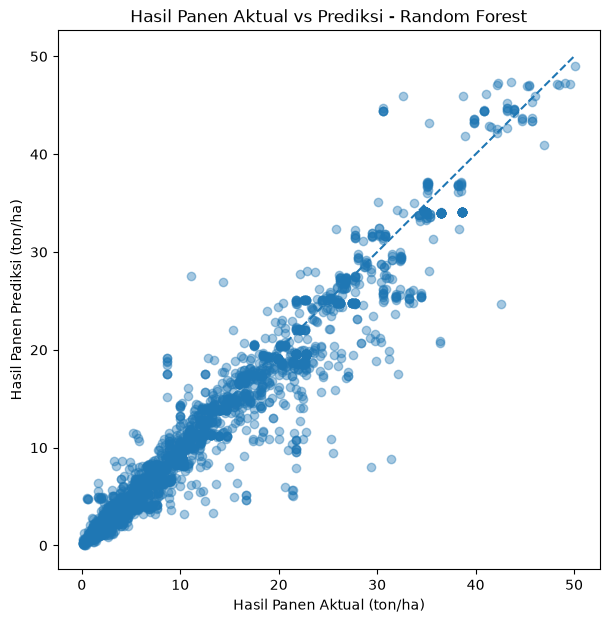

In [25]:
# Mengimpor pustaka untuk membuat visualisasi
import matplotlib.pyplot as plt

# MENGUBAH SATUAN DARI hg/ha KE ton/ha

# Mengubah hasil panen aktual dari hg/ha menjadi ton/ha
actual_yield_ton = actual_yield / 10000

# Mengubah hasil prediksi Random Forest dari hg/ha menjadi ton/ha
predicted_yield_rf_ton = predicted_yield_rf / 10000

# MEMBUAT GRAFIK HASIL PANEN AKTUAL VS PREDIKSI

# Mengatur ukuran grafik
plt.figure(figsize=(7, 7))

# Membuat grafik sebar untuk membandingkan hasil aktual dengan hasil prediksi
plt.scatter(
    actual_yield_ton,
    predicted_yield_rf_ton,
    alpha=0.4
)


# Menentukan nilai minimum dan maksimum untuk batas grafik
min_val = min(
    actual_yield_ton.min(),
    predicted_yield_rf_ton.min()
)

max_val = max(
    actual_yield_ton.max(),
    predicted_yield_rf_ton.max()
)


# Membuat garis yang menunjukkan kondisi ketika hasil prediksi
# sama persis dengan hasil aktual
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

# MEMBERIKAN KETERANGAN PADA GRAFIK

# Memberikan nama pada sumbu horizontal dan vertikal
plt.xlabel("Hasil Panen Aktual (ton/ha)")
plt.ylabel("Hasil Panen Prediksi (ton/ha)")

# Memberikan judul pada grafik
plt.title(
    "Hasil Panen Aktual vs Prediksi - Random Forest"
)

# Menampilkan grafik
plt.show()

Pada tahap ini, kita membuat grafik untuk mengecek seberapa dekat hasil prediksi Random Forest dengan hasil panen sebenarnya. Jadi, grafik ini bukan untuk melatih model lagi, tetapi untuk memvisualisasikan kualitas prediksi model.

Pertama, hasil panen dalam dataset masih menggunakan satuan hg/ha. Karena satuan tersebut kurang familiar bagi orang awam, kita mengubahnya menjadi ton/ha dengan membagi nilainya dengan 10.000, karena 1 ton setara dengan 10.000 hg. Setelah itu, hasil panen aktual dan hasil prediksi Random Forest digunakan sebagai sumbu grafik.

Pada grafik, sumbu X (horizontal) menunjukkan hasil panen yang sebenarnya, sedangkan sumbu Y (vertikal) menunjukkan hasil panen yang diprediksi oleh Random Forest. Setiap titik mewakili satu data tanaman pada suatu wilayah dan tahun.

Garis putus-putus diagonal adalah garis kondisi ideal. Misalnya, jika hasil panen sebenarnya 20 ton/ha dan model juga memprediksi 20 ton/ha, titiknya akan berada tepat di garis tersebut. Jadi, semakin dekat suatu titik dengan garis putus-putus, semakin akurat prediksi model untuk data tersebut.

Dari grafik terlihat bahwa sebagian besar titik, terutama pada rentang hasil panen rendah hingga sedang (di bawah sekitar 25 ton/ha), menempel cukup rapat dengan garis diagonal. Ini menunjukkan bahwa model mampu memprediksi dengan cukup akurat pada rentang tersebut. Namun, pada rentang hasil panen yang lebih tinggi, sebaran titik mulai menjauh dari garis, baik ke arah lebih rendah maupun lebih tinggi dari nilai sebenarnya. Hal ini mengindikasikan bahwa model masih kurang stabil dalam memprediksi hasil panen ekstrem, kemungkinan karena jumlah data pada rentang tersebut lebih sedikit dibandingkan data dengan hasil panen rendah hingga sedang.

# 7. Penerapan (Deployment)

In [26]:
import joblib

# Simpan model terbaik (Random Forest)
joblib.dump(rf_model, "rf_model.pkl")

# Simpan baseline map (rata-rata log_yield per Area+Item) dan global_mean
joblib.dump(baseline_map, "baseline_map.pkl")
joblib.dump(global_mean, "global_mean.pkl")

# Simpan daftar kolom one-hot Item hasil training (penting agar urutan/kolom konsisten saat inferensi)
joblib.dump(list(item_train.columns), "item_columns.pkl")

# Simpan daftar Area & Item unik untuk dropdown di UI
joblib.dump(sorted(df["Area"].unique().tolist()), "area_list.pkl")
joblib.dump(sorted(df["Item"].unique().tolist()), "item_list.pkl")

print("Artefak berhasil disimpan.")

Artefak berhasil disimpan.


Pada tahap ini, model dan seluruh komponen pendukungnya disimpan ke dalam file agar dapat digunakan kembali di luar notebook, misalnya untuk membangun aplikasi Streamlit, tanpa perlu melatih ulang model dari awal. Pustaka joblib digunakan untuk menyimpan objek Python ke dalam file dengan format .pkl.

Model Random Forest yang sudah dilatih (rf_model) disimpan ke dalam file rf_model.pkl karena model inilah yang nantinya digunakan untuk menghasilkan prediksi. Selain model, baseline_map dan global_mean juga ikut disimpan karena keduanya merupakan bagian penting dari cara kerja model ini: model tidak memprediksi hasil panen secara langsung, melainkan memprediksi selisih (residual) dari nilai rata-rata baseline. Tanpa baseline_map dan global_mean, hasil prediksi model tidak dapat dihitung kembali ke nilai aslinya.

Daftar kolom hasil one-hot encoding jenis tanaman (item_columns) juga disimpan untuk memastikan bahwa data baru yang dimasukkan pengguna nantinya memiliki struktur kolom yang sama persis dengan data yang digunakan saat training. Hal ini penting agar model tidak salah membaca fitur jenis tanaman.

Terakhir, daftar wilayah (area_list) dan jenis tanaman (item_list) yang unik disimpan agar dapat digunakan sebagai pilihan (dropdown) pada antarmuka aplikasi, sehingga pengguna cukup memilih dari daftar yang tersedia tanpa perlu mengetik secara manual. Dengan tersimpannya seluruh komponen ini, model beserta informasi pendukungnya siap dimuat kembali (joblib.load()) dan digunakan langsung di aplikasi Streamlit.

# 8. Kesimpulan

Analisis ini berhasil membangun model prediksi hasil panen berbasis wilayah, jenis tanaman, dan faktor iklim menggunakan pendekatan CRISP-DM. Temuan utama menunjukkan bahwa karakteristik agroklimat jangka panjang yang direpresentasikan oleh kombinasi wilayah dan jenis tanaman merupakan faktor paling dominan dalam menentukan hasil panen, dengan model baseline sederhana (rata-rata per kombinasi Area–Item) saja sudah mampu menjelaskan 87,81% variasi data (R² = 0,8781). Sebaliknya, variasi cuaca tahunan (curah hujan, suhu, penggunaan pestisida) memiliki korelasi yang sangat lemah terhadap hasil panen (0,00–0,11), sehingga peranannya lebih bersifat sebagai faktor koreksi kecil dibandingkan penentu utama.

Penambahan model machine learning yang memperhitungkan faktor iklim berhasil meningkatkan performa secara bertahap: Regresi Linear meningkatkan R² menjadi 0,9221, XGBoost menjadi 0,9321, dan Random Forest menjadi 0,9514 dengan MAE terendah sebesar 10.515,56 hg/ha (± 1,05 ton/ha). Random Forest dipilih sebagai model terbaik karena konsisten unggul di ketiga metrik evaluasi (MAE, RMSE, R²). Namun, visualisasi actual vs prediksi menunjukkan bahwa model masih kurang stabil dalam memprediksi hasil panen pada rentang nilai ekstrem/tinggi, kemungkinan karena keterbatasan jumlah data pada rentang tersebut.

Secara keseluruhan, model yang dihasilkan cukup layak digunakan sebagai alat bantu estimasi awal (decision-support sederhana) untuk perencanaan produksi pangan, terutama pada rentang hasil panen rendah hingga menengah. Meski demikian, karena dataset bersifat observasional, hasil ini hanya menunjukkan asosiasi dan tidak dapat diinterpretasikan sebagai hubungan sebab-akibat antara iklim dan hasil panen. Pengembangan lebih lanjut disarankan mencakup validasi dengan data yang lebih baru, penambahan fitur agronomis (jenis tanah, teknik budidaya, irigasi), dan analisis feature importance untuk memperkuat interpretabilitas model.